# Perhitungan Buffer Stock

Notebook ini menghitung buffer stock berdasarkan dataset penjualan dengan rumus:

**Buffer Stock = (Max Daily Sales × Max Lead Time) – (Avg Daily Sales × Avg Lead Time)**

Dimana:
- **Max Daily Sales**: Penjualan harian maksimum (jumlah barang tertinggi dalam 1 hari)
- **Max Lead Time**: Lead time maksimum yang mungkin terjadi
- **Avg Daily Sales**: Rata-rata penjualan harian
- **Avg Lead Time**: Rata-rata lead time normal


## 1. Import Library

In [18]:
%pip install pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style untuk visualisasi
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Load Dataset

In [19]:
%pip install openpyxl
import pandas as pd
import openpyxl

# Load dataset
file_path = 'Dataset_Forecasting_ARIMA_Lengkap.xlsx'
dataset = pd.read_excel(file_path, engine='openpyxl')

# Tampilkan beberapa baris pertama
print("Dataset Info:")
print(dataset.head())
print("\nJumlah data:", len(dataset))
print("\nKolom dataset:", dataset.columns.tolist())


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Dataset Info:
                  Date  AERIS10  GB-BB-10  GB-BB-30  BR45  BR75  GB-TP-CC  \
0  2025-01-01 00:00:00      0.0       0.0       0.0   0.0   0.0       0.0   
1  2025-01-02 00:00:00      0.0       0.0       1.0   0.0   0.0       0.0   
2  2025-01-03 00:00:00      0.0       1.0       0.0   0.0   0.0       0.0   
3  2025-01-04 00:00:00      0.0       0.0       0.0   0.0   0.0       0.0   
4  2025-01-05 00:00:00      0.0       0.0       0.0   0.0   0.0       0.0   

   GB-CNF-30  GB-CNF-10  GB-CNF-100  ...  GB-MYB-30  GB-MYB-10  GB-MYB-100  \
0        0.0        0.0         0.0  ...        0.0        0.0         0.0   
1        3.0       14.0         0.0  ...        0.0        3.0         0.0   
2       18.0       45.0         0.0  ...        0.0        0.0         0.0   
3        8.0        4.0         0.0  ...        0.0        0.0         0.0   
4        0.0        0.0         0.0  ...        0.0        0.0     

## 3. Preprocessing Data

In [20]:
import pandas as pd

# Convert Date column ke datetime format (coerce invalid values to NaT)
dataset['Date'] = pd.to_datetime(dataset['Date'], errors='coerce')

# Drop rows where Date could not be parsed (e.g. summary/header rows)
invalid_dates = dataset['Date'].isna().sum()
if invalid_dates > 0:
    print(f"⚠️ Menghapus {invalid_dates} baris dengan nilai tanggal tidak valid")
    dataset = dataset.dropna(subset=['Date'])

# Sort berdasarkan tanggal
dataset = dataset.sort_values('Date')

# Reset index
dataset = dataset.reset_index(drop=True)

print("Data setelah preprocessing:")
print(dataset.head())
print("\nRentang Tanggal:")
print(f"Tanggal Awal: {dataset['Date'].min()}")
print(f"Tanggal Akhir: {dataset['Date'].max()}")


⚠️ Menghapus 5 baris dengan nilai tanggal tidak valid
Data setelah preprocessing:
        Date  AERIS10  GB-BB-10  GB-BB-30  BR45  BR75  GB-TP-CC  GB-CNF-30  \
0 2025-01-01      0.0       0.0       0.0   0.0   0.0       0.0        0.0   
1 2025-01-02      0.0       0.0       1.0   0.0   0.0       0.0        3.0   
2 2025-01-03      0.0       1.0       0.0   0.0   0.0       0.0       18.0   
3 2025-01-04      0.0       0.0       0.0   0.0   0.0       0.0        8.0   
4 2025-01-05      0.0       0.0       0.0   0.0   0.0       0.0        0.0   

   GB-CNF-10  GB-CNF-100  ...  GB-MYB-30  GB-MYB-10  GB-MYB-100  GB-TP--NB  \
0        0.0         0.0  ...        0.0        0.0         0.0        0.0   
1       14.0         0.0  ...        0.0        3.0         0.0        0.0   
2       45.0         0.0  ...        0.0        0.0         0.0        2.0   
3        4.0         0.0  ...        0.0        0.0         0.0        0.0   
4        0.0         0.0  ...        0.0        0.0        

## 4. Identifikasi Kolom Produk

In [21]:
# Identifikasi kolom produk (semua kolom kecuali Date dan Total_Sales)
product_columns = [col for col in dataset.columns if col not in ['Date', 'Total_Sales']]

print("=" * 60)
print("DAFTAR PRODUK YANG AKAN DIANALISIS")
print("=" * 60)
print(f"Jumlah produk: {len(product_columns)}")
print(f"\nProduk: {', '.join(product_columns)}")
print("=" * 60)

DAFTAR PRODUK YANG AKAN DIANALISIS
Jumlah produk: 37

Produk: AERIS10, GB-BB-10, GB-BB-30, BR45, BR75, GB-TP-CC, GB-CNF-30, GB-CNF-10, GB-CNF-100, GB-CNF-250, GB-DS-30, GB-DS-10, GB-DS-100, GB-DS-250, EC45, EC75, GB-GF-30, GB-GF-10, GB-GF-250, GB-IB-30, GB-IB-10, GB-IB-100, GB-JOY-30, GB-JOY-10, GB-JOY-100, GB-LDR-30, GB-LDR-10, GB-LDR-250, GB-MYB-30, GB-MYB-10, GB-MYB-100, GB-TP--NB, GB-TC-30, GB-TC-10, GB-TC-250, TEETH10, GB-TP-TV


## 5. Hitung Statistik Pemakaian Harian per Produk

In [22]:

# Hitung statistik untuk setiap produk
product_stats = pd.DataFrame()

for product in product_columns:
    stats = {
        'Produk': product,
        'Pemakaian_Maksimum': dataset[product].quantile(0.95),  # Persentil ke-95, tahan outlier
        'Pemakaian_Rata_rata': dataset[product].mean(),
        'Standar_Deviasi': dataset[product].std()
    }
    product_stats = pd.concat([product_stats, pd.DataFrame([stats])], ignore_index=True)

print("=" * 80)
print("STATISTIK PEMAKAIAN HARIAN PER PRODUK")
print("=" * 80)
print(product_stats.to_string(index=False))
print("=" * 80)

# Tampilkan top 5 produk berdasarkan pemakaian rata-rata
print("\nTOP 5 PRODUK BERDASARKAN PEMAKAIAN RATA-RATA:")
print(product_stats.nlargest(5, 'Pemakaian_Rata_rata')[['Produk', 'Pemakaian_Rata_rata', 'Pemakaian_Maksimum']].to_string(index=False))


STATISTIK PEMAKAIAN HARIAN PER PRODUK
    Produk  Pemakaian_Maksimum  Pemakaian_Rata_rata  Standar_Deviasi
   AERIS10                 0.0             0.008219         0.116912
  GB-BB-10                 1.0             0.126027         0.663413
  GB-BB-30                 0.0             0.063014         0.376328
      BR45                 0.0             0.054795         0.366541
      BR75                 0.0             0.002740         0.052342
  GB-TP-CC                 1.0             0.339726         1.667295
 GB-CNF-30                20.0             4.479452        10.660739
 GB-CNF-10                23.4             4.397260        12.948482
GB-CNF-100                 0.0             0.016438         0.127329
GB-CNF-250                 0.0             0.002740         0.052342
  GB-DS-30                 3.0             0.676712         2.683820
  GB-DS-10                 4.0             0.800000         2.457552
 GB-DS-100                 0.0             0.013699         0.116

## 6. Definisi Lead Time

In [23]:
# Definisi Lead Time
avg_lead_time = 5.4   # hari (rata-rata)
max_lead_time = 7     # hari (maksimum / worst case)

print("=" * 60)
print("KOMPONEN LEAD TIME")
print("=" * 60)
print(f"  Avg Lead Time (Normal)      : {avg_lead_time} hari")
print(f"  Max Lead Time (Worst Case)  : {max_lead_time} hari")
print("=" * 60)


KOMPONEN LEAD TIME
  Avg Lead Time (Normal)      : 5.4 hari
  Max Lead Time (Worst Case)  : 7 hari


## 7. Perhitungan Buffer Stock per Produk

**Rumus:** `Buffer Stock = (Max Daily Sales × Max Lead Time) – (Avg Daily Sales × Avg Lead Time)`


In [24]:

# Hitung Buffer Stock untuk setiap produk menggunakan rumus:
# Buffer Stock = (Max Daily Sales × Max Lead Time) – (Avg Daily Sales × Avg Lead Time)

# Pastikan Pemakaian_Maksimum selalu >= Pemakaian_Rata_rata (hindari buffer negatif)
product_stats['Pemakaian_Maksimum'] = product_stats[['Pemakaian_Maksimum', 'Pemakaian_Rata_rata']].max(axis=1)

product_stats['Buffer_Stock'] = (
    (product_stats['Pemakaian_Maksimum'] * max_lead_time) -
    (product_stats['Pemakaian_Rata_rata'] * avg_lead_time)
).clip(lower=0)  # Buffer stock tidak boleh negatif

print("=" * 90)
print("PERHITUNGAN BUFFER STOCK PER PRODUK")
print("=" * 90)
print(f"Rumus: (Max Daily Sales × Max Lead Time) – (Avg Daily Sales × Avg Lead Time)")
print(f"       Max Lead Time = {max_lead_time} hari | Avg Lead Time = {avg_lead_time} hari")
print(f"       Max Daily Sales = max(Persentil-95, Rata-rata) → Tidak ada nilai negatif")
print("=" * 90)
print(product_stats[['Produk', 'Pemakaian_Maksimum', 'Pemakaian_Rata_rata', 'Buffer_Stock']].to_string(index=False))
print("=" * 90)

# Tampilkan produk dengan buffer stock tertinggi
print("\n📦 TOP 10 PRODUK DENGAN BUFFER STOCK TERTINGGI:")
print(product_stats.nlargest(10, 'Buffer_Stock')[['Produk', 'Pemakaian_Maksimum', 'Pemakaian_Rata_rata', 'Buffer_Stock']].to_string(index=False))


PERHITUNGAN BUFFER STOCK PER PRODUK
Rumus: (Max Daily Sales × Max Lead Time) – (Avg Daily Sales × Avg Lead Time)
       Max Lead Time = 7 hari | Avg Lead Time = 5.4 hari
       Max Daily Sales = max(Persentil-95, Rata-rata) → Tidak ada nilai negatif
    Produk  Pemakaian_Maksimum  Pemakaian_Rata_rata  Buffer_Stock
   AERIS10            0.008219             0.008219      0.013151
  GB-BB-10            1.000000             0.126027      6.319452
  GB-BB-30            0.063014             0.063014      0.100822
      BR45            0.054795             0.054795      0.087671
      BR75            0.002740             0.002740      0.004384
  GB-TP-CC            1.000000             0.339726      5.165479
 GB-CNF-30           20.000000             4.479452    115.810959
 GB-CNF-10           23.400000             4.397260    140.054795
GB-CNF-100            0.016438             0.016438      0.026301
GB-CNF-250            0.002740             0.002740      0.004384
  GB-DS-30            3.

## 8. Safety Stock per Produk (Perhitungan Tambahan)

Sebagai perbandingan, kita juga dapat menghitung Safety Stock menggunakan metode standar deviasi:

**Safety Stock = Z-score × Standard Deviation × √Lead Time**

Dimana Z-score untuk service level 95% = 1.65

In [25]:
# Hitung Safety Stock untuk setiap produk (metode alternatif)
z_score = 1.65  # untuk service level 95%
sqrt_avg_lead_time = avg_lead_time ** 0.5
product_stats['Safety_Stock_95%'] = z_score * product_stats['Standar_Deviasi'] * sqrt_avg_lead_time

print("=" * 80)
print("PERHITUNGAN SAFETY STOCK PER PRODUK (Service Level 95%)")
print("=" * 80)
print(f"Z-score: {z_score} | √Avg Lead Time: {sqrt_avg_lead_time:.4f}")
print("=" * 80)
print(product_stats[['Produk', 'Standar_Deviasi', 'Safety_Stock_95%']].to_string(index=False))
print("=" * 80)

# Perbandingan Buffer Stock vs Safety Stock
comparison_df = product_stats.nlargest(10, 'Buffer_Stock')[['Produk', 'Buffer_Stock', 'Safety_Stock_95%']]
print("\n📊 PERBANDINGAN BUFFER STOCK vs SAFETY STOCK (Top 10):")
print(comparison_df.to_string(index=False))


PERHITUNGAN SAFETY STOCK PER PRODUK (Service Level 95%)
Z-score: 1.65 | √Avg Lead Time: 2.3238
    Produk  Standar_Deviasi  Safety_Stock_95%
   AERIS10         0.116912          0.448272
  GB-BB-10         0.663413          2.543695
  GB-BB-30         0.376328          1.442937
      BR45         0.366541          1.405409
      BR75         0.052342          0.200694
  GB-TP-CC         1.667295          6.392833
 GB-CNF-30        10.660739         40.875977
 GB-CNF-10        12.948482         49.647762
GB-CNF-100         0.127329          0.488210
GB-CNF-250         0.052342          0.200694
  GB-DS-30         2.683820         10.290447
  GB-DS-10         2.457552          9.422876
 GB-DS-100         0.116396          0.446293
 GB-DS-250         0.090410          0.346656
      EC45         0.449513          1.723548
      EC75         0.052342          0.200694
  GB-GF-30         1.468393          5.630193
  GB-GF-10         1.899963          7.284940
 GB-GF-250         0.052342    

## 9. Visualisasi Buffer Stock per Produk

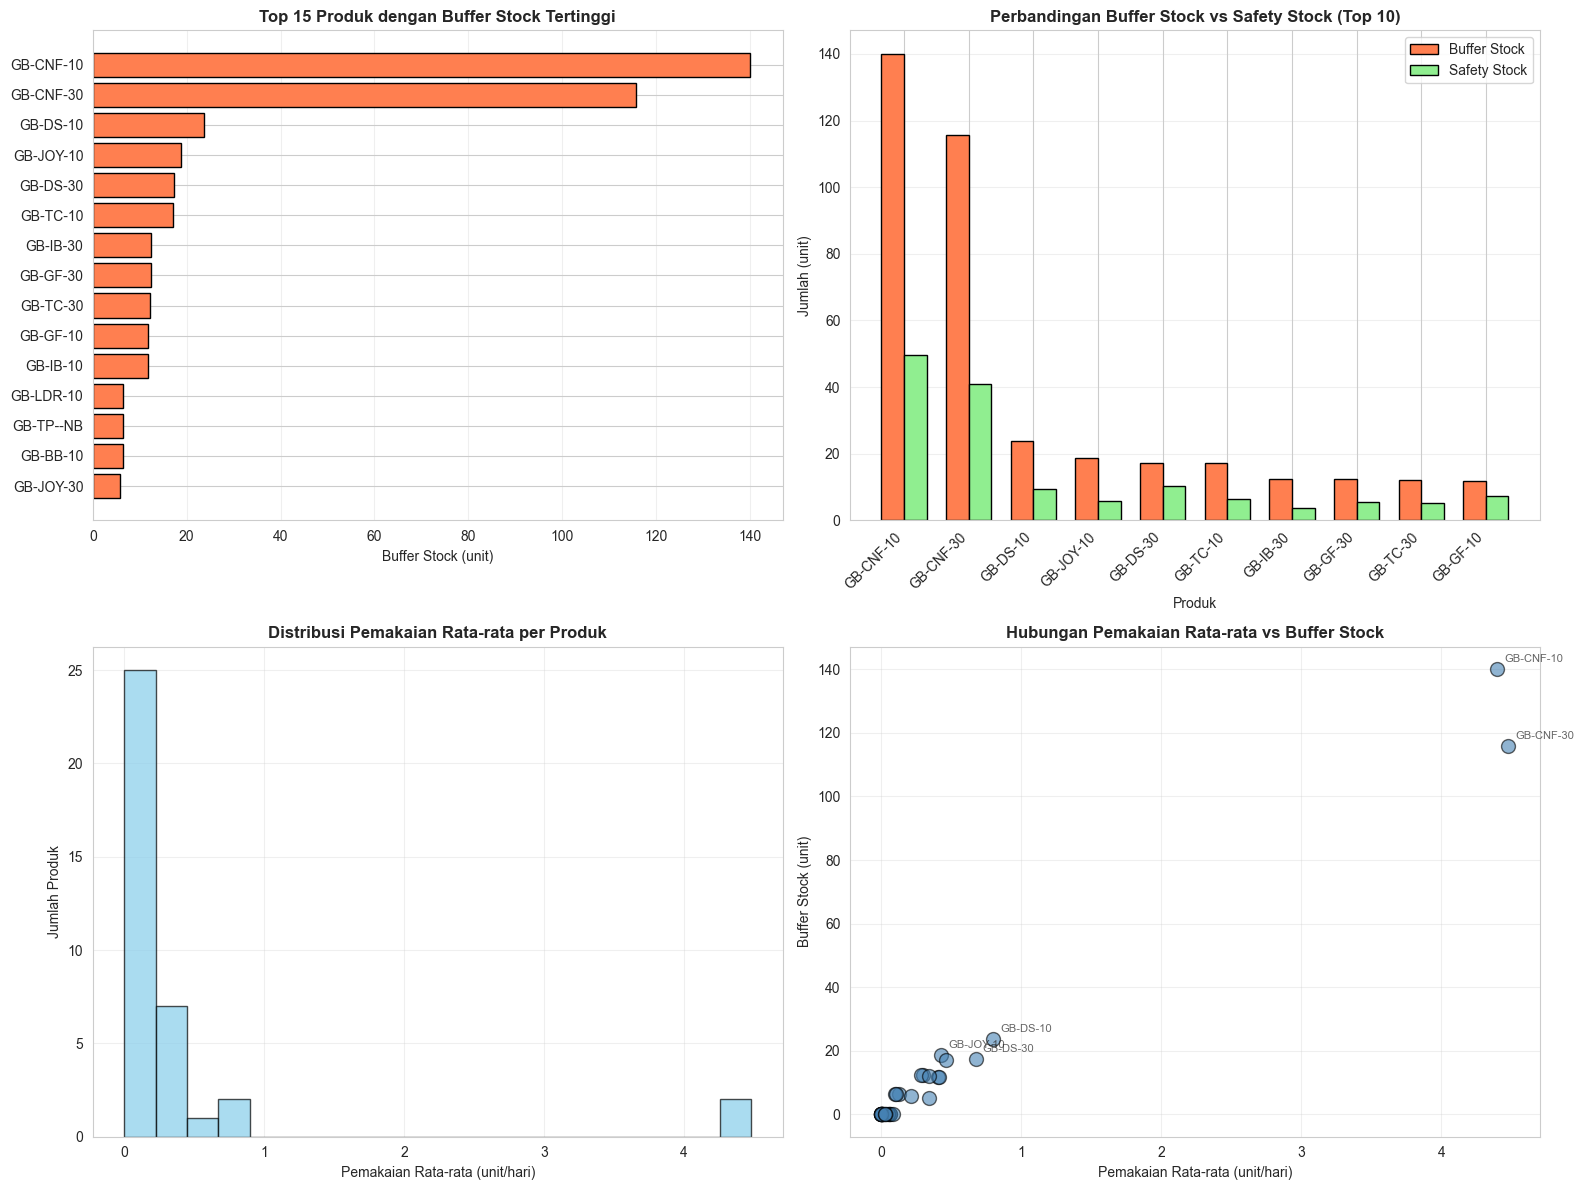

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Visualisasi Buffer Stock per Produk
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Top 15 Produk dengan Buffer Stock Tertinggi
top_15_buffer = product_stats.nlargest(15, 'Buffer_Stock').sort_values('Buffer_Stock', ascending=True)
axes[0, 0].barh(top_15_buffer['Produk'], top_15_buffer['Buffer_Stock'], color='coral', edgecolor='black')
axes[0, 0].set_title('Top 15 Produk dengan Buffer Stock Tertinggi', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Buffer Stock (unit)')
axes[0, 0].grid(True, axis='x', alpha=0.3)

# Plot 2: Perbandingan Buffer Stock vs Safety Stock (Top 10)
top_10_comparison = product_stats.nlargest(10, 'Buffer_Stock')
x_pos = np.arange(len(top_10_comparison))
width = 0.35

axes[0, 1].bar(x_pos - width/2, top_10_comparison['Buffer_Stock'], width, label='Buffer Stock', color='coral', edgecolor='black')
axes[0, 1].bar(x_pos + width/2, top_10_comparison['Safety_Stock_95%'], width, label='Safety Stock', color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Perbandingan Buffer Stock vs Safety Stock (Top 10)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Produk')
axes[0, 1].set_ylabel('Jumlah (unit)')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(top_10_comparison['Produk'], rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(True, axis='y', alpha=0.3)

# Plot 3: Distribusi Pemakaian Rata-rata per Produk
axes[1, 0].hist(product_stats['Pemakaian_Rata_rata'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Distribusi Pemakaian Rata-rata per Produk', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Pemakaian Rata-rata (unit/hari)')
axes[1, 0].set_ylabel('Jumlah Produk')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Scatter Plot - Pemakaian Rata-rata vs Buffer Stock
axes[1, 1].scatter(product_stats['Pemakaian_Rata_rata'], product_stats['Buffer_Stock'], 
                   s=100, alpha=0.6, c='steelblue', edgecolor='black')
axes[1, 1].set_title('Hubungan Pemakaian Rata-rata vs Buffer Stock', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Pemakaian Rata-rata (unit/hari)')
axes[1, 1].set_ylabel('Buffer Stock (unit)')
axes[1, 1].grid(True, alpha=0.3)

# Tambahkan label untuk produk dengan buffer stock tertinggi
top_5_label = product_stats.nlargest(5, 'Buffer_Stock')
for idx, row in top_5_label.iterrows():
    axes[1, 1].annotate(row['Produk'], 
                       (row['Pemakaian_Rata_rata'], row['Buffer_Stock']),
                       xytext=(5, 5), textcoords='offset points', 
                       fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

## 10. Ringkasan Hasil & Rekomendasi

In [27]:
# Ringkasan Statistik Keseluruhan
total_buffer_stock = product_stats['Buffer_Stock'].sum()
total_safety_stock = product_stats['Safety_Stock_95%'].sum()
avg_buffer_stock = product_stats['Buffer_Stock'].mean()

print("\n" + "=" * 80)
print("RINGKASAN HASIL PERHITUNGAN BUFFER STOCK")
print("=" * 80)
print(f"Rumus        : (Max Daily Sales × Max Lead Time) – (Avg Daily Sales × Avg Lead Time)")
print(f"Jumlah Produk Dianalisis        : {len(product_stats)} produk")
print(f"Avg Lead Time                   : {avg_lead_time} hari")
print(f"Max Lead Time                   : {max_lead_time} hari")
print(f"Total Buffer Stock (Semua Produk): {total_buffer_stock:.2f} unit")
print(f"Total Safety Stock (Semua Produk): {total_safety_stock:.2f} unit")
print(f"Rata-rata Buffer Stock per Produk: {avg_buffer_stock:.2f} unit")
print("=" * 80)

print("\n📊 TOP 10 PRODUK PRIORITAS UNTUK BUFFER STOCK:")
print("=" * 80)
top_10 = product_stats.nlargest(10, 'Buffer_Stock')[['Produk', 'Pemakaian_Rata_rata', 'Pemakaian_Maksimum', 'Buffer_Stock', 'Safety_Stock_95%']]
top_10_display = top_10.copy()
top_10_display.columns = ['Produk', 'Avg Daily Sales', 'Max Daily Sales', 'Buffer Stock', 'Safety Stock']
print(top_10_display.to_string(index=False))
print("=" * 80)

print("\n💡 REKOMENDASI:")
print("-" * 80)
print(f"1. Prioritaskan produk dengan buffer stock tertinggi untuk dijaga ketersediaannya")
print(f"2. Total buffer stock yang diperlukan untuk semua produk: {total_buffer_stock:.2f} unit")
print(f"3. Produk dengan buffer stock > {avg_buffer_stock:.0f} unit memerlukan perhatian khusus")
print(f"4. Tinjau ulang buffer stock secara berkala sesuai perubahan pola permintaan")
print("=" * 80)



RINGKASAN HASIL PERHITUNGAN BUFFER STOCK
Rumus        : (Max Daily Sales × Max Lead Time) – (Avg Daily Sales × Avg Lead Time)
Jumlah Produk Dianalisis        : 37 produk
Avg Lead Time                   : 5.4 hari
Max Lead Time                   : 7 hari
Total Buffer Stock (Semua Produk): 424.27 unit
Total Safety Stock (Semua Produk): 180.79 unit
Rata-rata Buffer Stock per Produk: 11.47 unit

📊 TOP 10 PRODUK PRIORITAS UNTUK BUFFER STOCK:
   Produk  Avg Daily Sales  Max Daily Sales  Buffer Stock  Safety Stock
GB-CNF-10         4.397260             23.4    140.054795     49.647762
GB-CNF-30         4.479452             20.0    115.810959     40.875977
 GB-DS-10         0.800000              4.0     23.680000      9.422876
GB-JOY-10         0.430137              3.0     18.677260      5.746000
 GB-DS-30         0.676712              3.0     17.345753     10.290447
 GB-TC-10         0.463014              2.8     17.099726      6.445924
 GB-IB-30         0.282192              2.0     12.476

## 11. Export Hasil ke CSV

In [28]:
# Siapkan dataframe untuk export dengan informasi lengkap
export_df = product_stats.copy()
export_df.columns = [
    'Produk',
    'Max_Daily_Sales',
    'Avg_Daily_Sales',
    'Standar_Deviasi',
    'Buffer_Stock_Unit',
    'Safety_Stock_95percent_Unit'
]

# Tambahkan informasi lead time ke dalam dataframe export
export_df['Avg_Lead_Time_Hari'] = avg_lead_time
export_df['Max_Lead_Time_Hari'] = max_lead_time

# Tambahkan kolom keterangan rumus
export_df['Rumus'] = f'(Max Daily Sales x {max_lead_time}) - (Avg Daily Sales x {avg_lead_time})'

# Urutkan berdasarkan buffer stock tertinggi
export_df = export_df.sort_values('Buffer_Stock_Unit', ascending=False)

# Round semua angka ke 2 desimal
numeric_columns = export_df.select_dtypes(include=[np.number]).columns
export_df[numeric_columns] = export_df[numeric_columns].round(2)

# Save to CSV
output_file = 'buffer_stock_per_produk.csv'
export_df.to_csv(output_file, index=False, encoding='utf-8-sig')

print(f"✅ Hasil analisis buffer stock per produk berhasil disimpan ke:")
print(f"   {output_file}")
print(f"\n📊 Total: {len(export_df)} produk")
print(f"\nPreview 10 produk teratas:")
print(export_df[['Produk', 'Avg_Daily_Sales', 'Max_Daily_Sales', 'Buffer_Stock_Unit']].head(10).to_string(index=False))


✅ Hasil analisis buffer stock per produk berhasil disimpan ke:
   buffer_stock_per_produk.csv

📊 Total: 37 produk

Preview 10 produk teratas:
   Produk  Avg_Daily_Sales  Max_Daily_Sales  Buffer_Stock_Unit
GB-CNF-10             4.40             23.4             140.05
GB-CNF-30             4.48             20.0             115.81
 GB-DS-10             0.80              4.0              23.68
GB-JOY-10             0.43              3.0              18.68
 GB-DS-30             0.68              3.0              17.35
 GB-TC-10             0.46              2.8              17.10
 GB-IB-30             0.28              2.0              12.48
 GB-GF-30             0.30              2.0              12.37
 GB-TC-30             0.35              2.0              12.14
 GB-GF-10             0.41              2.0              11.81
